# Week 23-2 · MLT-07 — Reinforcement Learning in Trading
### Practice notebook — the lecture's RL trader, reproduced on the **real shipped data**

Instructor: **Dr Tom Starke** (PhD Physics; ex-Rolls-Royce, hedge funds & prop firms; CEO of AAAQuants).

Reinforcement learning trains an **agent** to act in an **environment** so as to maximise **reward**. The
lecture "gamifies" trading: the agent sees a market **state**, chooses an **action** (hold / long / short),
and receives a **reward** (P&L). It learns by updating a **Q-table** with the **Bellman equation**, trading
off **exploration** vs **exploitation** with an ε schedule.

The shipped notebooks (`RL Main.ipynb`, `ReinforcementLearningLecture.ipynb`) implement a **deep-Q network**
in Keras/TensorFlow, with experience replay and a double Q-network. TensorFlow isn't installed here, so this
notebook reproduces the **same algorithm with tabular Q-learning in pure NumPy** — which is exactly the
Bellman update the lecture teaches, just with a lookup table instead of a neural net approximating it. Every
number below is computed live.

| Section | What it reproduces |
|---|---|
| 1 | The vocabulary: state, action, reward, policy, ε, Q-table, Bellman |
| 2 | The **marshmallow** delayed-gratification Q-table (matches the shipped `Bellman.ipynb` answer) |
| 3 | A 3-action Q-learning **trading engine** (hold / long / short) |
| 4 | Test 1 — a clean **sine wave** (the agent learns the cycle) |
| 5 | Test 2 — a **noisy sine wave** (signal degrades) |
| 6 | Test 3 — the **real shipped market series** (converges to buy-and-hold — the slide's exact finding) |
| 7 | The **6 shipped reward functions** and why design is hard |
| 8 | The **ε-decay** schedule + experience replay + the DQN architecture |
| 9 | The four pictures |


## 0 · Setup

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
np.random.seed(16)                       # the lecture's set_seed(16)
pd.set_option("display.width", 120)
DATA = os.getcwd()
print("market data file:", [f for f in os.listdir(DATA) if f.endswith('.csv')])


market data file: ['market_daily.csv']


## 1 · The machine-learning ground rules — over-fitting (bias vs variance)

RL sits on top of ordinary machine learning, so its problems are ordinary ML problems, amplified. The first is
**over-fitting**, framed as the bias–variance trade-off. Too few parameters (a straight line through a curve)
**under-fits** — that's bias. Too many (a degree-15 polynomial) fits every wiggle of the noise and swings
wildly between the points — that's variance. We fit a quadratic truth three ways and judge on data never seen.

In [2]:
rng = np.random.default_rng(0)
xtr = np.sort(rng.uniform(-3, 3, 25)); ytr = 0.5*xtr**2 - xtr + 2 + rng.normal(0, 1.2, len(xtr))
xte = np.sort(rng.uniform(-3, 3, 200)); yte = 0.5*xte**2 - xte + 2 + rng.normal(0, 1.2, len(xte))
for deg in (2, 15):
    c = np.polyfit(xtr, ytr, deg)
    tr = np.mean((np.polyval(c, xtr) - ytr)**2)
    te = np.mean((np.polyval(c, xte) - yte)**2)
    print(f"degree {deg:2d}:  train MSE {tr:8.2f}   |   out-of-sample MSE {te:12.2f}")
print("\nThe degree-15 fit scores slightly better in training but its out-of-sample error explodes —")
print("classic high-variance over-fitting. There is NO universal right number of parameters; it depends")
print("on the data, which is why serious finance leans on simple models (linear reg, PCA, naive Bayes).")


degree  2:  train MSE     0.69   |   out-of-sample MSE         2.15
degree 15:  train MSE     0.37   |   out-of-sample MSE       705.41

The degree-15 fit scores slightly better in training but its out-of-sample error explodes —
classic high-variance over-fitting. There is NO universal right number of parameters; it depends
on the data, which is why serious finance leans on simple models (linear reg, PCA, naive Bayes).


## 2 · Why finance is harder — fat tails

Black–Scholes assumes returns follow a Gaussian bell curve. They don't. Real markets have **fat tails**: a
crash is not one-in-a-billion but hundreds or thousands of times more likely than the normal curve admits.
Returns resemble **Cauchy / Lévy-stable** laws whose sample mean and variance never settle down.

In [3]:
from scipy import stats
z = 5.0
p_norm   = 2 * stats.norm.sf(z)          # P(|X| > 5) under a Gaussian
p_cauchy = 2 * stats.cauchy.sf(z)        # under a standard Cauchy (the fat-tailed law)
print(f"P(|move| > 5 sd)   Gaussian : {p_norm:.3e}")
print(f"P(|move| > 5 sd)   Cauchy   : {p_cauchy:.3e}")
print(f"fat-tailed law makes a 5-sigma move ~{p_cauchy/p_norm:,.0f}x more likely than the bell curve")
print("\nWorse: draw more Cauchy samples and the running mean keeps jumping — it never converges.")
run_mean = np.cumsum(stats.cauchy.rvs(size=5000, random_state=7)) / np.arange(1, 5001)
print(f"Cauchy running mean after 1k / 3k / 5k draws: {run_mean[999]:.2f} / {run_mean[2999]:.2f} / {run_mean[4999]:.2f}")


P(|move| > 5 sd)   Gaussian : 5.733e-07
P(|move| > 5 sd)   Cauchy   : 1.257e-01
fat-tailed law makes a 5-sigma move ~219,196x more likely than the bell curve

Worse: draw more Cauchy samples and the running mean keeps jumping — it never converges.
Cauchy running mean after 1k / 3k / 5k draws: -1.13 / 0.26 / -0.20


## 3 · Perception bias — only autocorrelation makes a chart predictable

Dr Starke shows two charts and asks which is more predictable; almost everyone guesses wrong, because the eye
cannot tell. A pure **random walk** is littered with convincing head-and-shoulders and trends, yet its next
tick is a coin toss. The *only* thing that ever makes a series predictable is **autocorrelation** — and every
technical indicator is just a repackaging of it.

In [4]:
rng = np.random.default_rng(3)
rw = np.cumsum(rng.normal(0, 1, 4000))                       # random walk
mr = np.zeros(4000)                                          # mean-reverting AR(1), phi < 0
for t in range(1, 4000):
    mr[t] = -0.5 * mr[t-1] + rng.normal(0, 1)
def lag1_autocorr(series):
    r = np.diff(series)
    return np.corrcoef(r[:-1], r[1:])[0, 1]
print(f"random-walk    lag-1 autocorrelation of returns : {lag1_autocorr(rw):+.3f}   (inside noise -> no edge)")
print(f"mean-reverting lag-1 autocorrelation of returns : {lag1_autocorr(mr):+.3f}   (clearly significant)")
print("\nThe random walk looks tradable but isn't; the predictable one is only predictable because of")
print("that non-zero autocorrelation. Indicators smooth noise but also lag and can invent autocorrelation.")


random-walk    lag-1 autocorrelation of returns : +0.022   (inside noise -> no edge)
mean-reverting lag-1 autocorrelation of returns : -0.749   (clearly significant)

The random walk looks tradable but isn't; the predictable one is only predictable because of
that non-zero autocorrelation. Indicators smooth noise but also lag and can invent autocorrelation.


## 4 · Predict **returns**, not prices

A blog once went viral for "perfectly predicting" stock prices. It had really predicted *yesterday's* price
for today — and since tomorrow's price is always close to today's, the chart looked flawless. But trading
needs **direction**, and on returns that same trick is a coin toss. Always model the percentage return.

In [5]:
mkt0 = pd.read_csv("market_daily.csv", index_col=0, parse_dates=True)["close"].values
naive_pred = mkt0[:-1]                       # "predict" today's price = yesterday's price
actual     = mkt0[1:]
ss_res = np.sum((actual - naive_pred)**2)
ss_tot = np.sum((actual - actual.mean())**2)
r2_price = 1 - ss_res/ss_tot
ret = np.diff(mkt0) / mkt0[:-1]
dir_acc = np.mean(np.sign(ret[:-1]) == np.sign(ret[1:]))     # yesterday's direction predicts today's?
print(f"'predict price = yesterday's price'  ->  R^2 on PRICES  = {r2_price:.4f}   (looks amazing)")
print(f"same naive rule judged on DIRECTION   ->  accuracy      = {dir_acc:.1%}   (a coin toss)")
print("\nThe price R^2 is a mirage. Model R = (P_t - P_t-1)/P_t-1, never the raw price.")


'predict price = yesterday's price'  ->  R^2 on PRICES  = 0.9995   (looks amazing)
same naive rule judged on DIRECTION   ->  accuracy      = 49.7%   (a coin toss)

The price R^2 is a mirage. Model R = (P_t - P_t-1)/P_t-1, never the raw price.


## 5 · The vocabulary of reinforcement learning

From the lecture summary — RL follows a **Markov Decision Process** with three primary elements:

* **State** `s` — the current situation of the environment (the market). We encode it with features:
  percentage change, RSI, volatility, moving-average cross, time-of-day / day-of-week, other instruments,
  even alternative data. It should capture everything needed to act.
* **Action** `a` — what the agent does. In trading: **Buy (go long)**, **Sell (go short / exit)**, **Hold**.
  The shipped code uses `0 = hold`, `1 = short or exit long`, `2 = long or exit short`.
* **Reward** `r` — the environment's feedback: P&L over the interval, direction of the move, final trade
  return, Sharpe, etc. It **rewards desired behaviour and punishes the undesired**.
* **Policy** `π` — the rule mapping state → action. It swings between two modes via **ε**:
  **exploration** (try random actions early, when it knows nothing) and **exploitation** (take the
  best-known action later). ε shrinks as the agent learns.
* **Q-table** `Q(s,a)` — a table: rows = states, columns = actions, entries = expected cumulative reward.
* **Bellman equation** — how the Q-table is updated: an action's value is its immediate reward plus the
  discounted value of the best action available in the state it leads to.


In [6]:
# The Bellman equation is the whole engine. Two equivalent forms the lecture uses:
#
#   target form :  Q(s,a)  =  r(s,a)  +  gamma * max_a' Q(s', a')
#   update form :  Q(s,a) <-  Q(s,a)  +  alpha * [ r + gamma * max_a' Q(s',a')  -  Q(s,a) ]
#
#   r      = immediate reward of action a
#   gamma  = discount factor (0..1): 0 = myopic, ->1 = far-sighted
#   s'     = the state we land in after taking a
#   alpha  = learning rate: how much each new experience moves the estimate
#
# Everything in this notebook is built on this one line.
def bellman_update(Q, s, a, r, s_next, alpha=0.1, gamma=0.95):
    best_next = Q[s_next].max()
    Q[s][a] += alpha * (r + gamma * best_next - Q[s][a])
    return Q[s][a]
print("Bellman update defined.")


Bellman update defined.


## 6 · Delayed gratification — the marshmallow Q-table

The lecture's clearest RL example is the **marshmallow experiment**: eat one now, or wait seven minutes and
get two. It captures the trading problem exactly — *a small reward now versus a larger reward later, when
decisions have repercussions far in the future.*

Rules (from the shipped `Bellman.ipynb`): eating at any step gives **1**; waiting the full 7 steps gives
**2**; discount **γ = 0.9**. Because there is no immediate reward for waiting, the value of *Wait* is purely
the discounted value of the best future action: `Q_wait(t) = γ · max(Q(t+1))`. We solve it by backward
induction and reproduce the shipped answer table exactly.

In [7]:
gamma = 0.9
# time step 7 = the very start (7 minutes left); step 1 = last minute before the treat.
Q_eat  = {7: 2.0}          # at the final step, eating yields the full 2 marshmallows
Q_wait = {7: 2.0}          # and waiting the last instant also yields 2
for t in range(6, 0, -1):
    Q_eat[t]  = 1.0                                  # eating early always gives just 1
    Q_wait[t] = gamma * max(Q_eat[t+1], Q_wait[t+1]) # discounted value of the best future action

table = pd.DataFrame({"Time": range(1, 8),
                      "Eat":  [Q_eat[t]  for t in range(1, 8)],
                      "Wait": [round(Q_wait[t], 2) for t in range(1, 8)]})
print(table.to_string(index=False))
print("\nAt every step Wait > Eat, so the optimal policy is to WAIT — delayed gratification wins.")
print("This matches the shipped Bellman.ipynb answer (Wait: 1.06,1.18,1.31,1.46,1.62,1.80,2.00).")


 Time  Eat  Wait
    1  1.0  1.06
    2  1.0  1.18
    3  1.0  1.31
    4  1.0  1.46
    5  1.0  1.62
    6  1.0  1.80
    7  2.0  2.00

At every step Wait > Eat, so the optimal policy is to WAIT — delayed gratification wins.
This matches the shipped Bellman.ipynb answer (Wait: 1.06,1.18,1.31,1.46,1.62,1.80,2.00).


## 7 · A Q-learning trading engine (hold / long / short)

Now the same Bellman update, applied to trading. The agent walks through a price series one bar at a time.
Its **state** is a discretised trend signal (how far price sits above/below its own moving average, in
standard-deviation buckets) together with its **current position**. Its **actions** are the lecture's three:
`0 hold`, `1 short/exit-long`, `2 long/exit-short`. Its **reward** each step is the mark-to-market P&L of the
position it holds, minus a small cost whenever it changes position (so it can't churn for free).

This is deliberately a *tabular* stand-in for the shipped Keras DQN: the neural net there simply
*approximates* this same `Q(s,a)` when the state space is too large to tabulate.

In [8]:
def make_signal(prices, ma_window=20, n_bins=6):
    '''Discretise (price - MA)/rolling-std into n_bins buckets -> the "trend" part of the state.'''
    s = pd.Series(prices)
    ma = s.rolling(ma_window).mean()
    sd = s.rolling(ma_window).std()
    z = ((s - ma) / sd).fillna(0.0).values
    edges = np.quantile(z[ma_window:], np.linspace(0, 1, n_bins + 1)[1:-1])  # inner bin edges
    sig = np.digitize(z, edges)               # 0..n_bins-1
    return sig, z

def train_qtrader(prices, sig, n_bins=6, epochs=30, alpha=0.1, gamma=0.95,
                  cost=0.0005, eps0=1.0, eps_min=0.01, seed=16):
    '''Tabular Q-learning. Q[signal_bin, position_idx, action]; position in {-1,0,1} -> idx {0,1,2}.'''
    rng = np.random.default_rng(seed)
    Q = np.zeros((n_bins, 3, 3))
    rets = np.diff(prices) / prices[:-1]
    n = len(rets)
    for e in range(epochs):
        eps = max(eps_min, eps0 * (0.85 ** e))          # exploration decays each epoch
        pos = 0
        for t in range(n - 1):
            s = (sig[t], pos + 1)
            if rng.random() < eps:
                a = rng.integers(0, 3)
            else:
                a = int(Q[s].argmax())
            new_pos = pos
            if a == 2 and pos <= 0:  new_pos = 1        # long / exit short
            elif a == 1 and pos >= 0: new_pos = -1       # short / exit long
            r = new_pos * rets[t + 1] - (cost if new_pos != pos else 0.0)
            s_next = (sig[t + 1], new_pos + 1)
            Q[s[0], s[1], a] += alpha * (r + gamma * Q[s_next].max() - Q[s[0], s[1], a])
            pos = new_pos
    return Q

def eval_qtrader(prices, sig, Q, cost=0.0005):
    '''Greedy (epsilon=0) walk-through; returns the strategy's per-step returns and the position path.'''
    rets = np.diff(prices) / prices[:-1]
    pos, positions, strat = 0, [], []
    for t in range(len(rets) - 1):
        a = int(Q[sig[t], pos + 1].argmax())
        new_pos = pos
        if a == 2 and pos <= 0:  new_pos = 1
        elif a == 1 and pos >= 0: new_pos = -1
        strat.append(new_pos * rets[t + 1] - (cost if new_pos != pos else 0.0))
        positions.append(new_pos); pos = new_pos
    return np.array(strat), np.array(positions), rets[1:]

def summarise(strat_ret, mkt_ret, periods=252):
    def stats(r):
        eq = np.cumprod(1 + r); tot = eq[-1] - 1
        sharpe = r.mean() / r.std() * np.sqrt(periods) if r.std() else np.nan
        mdd = (eq / np.maximum.accumulate(eq) - 1).min()
        return tot, sharpe, mdd, eq
    ts, shs, mds, eqs = stats(strat_ret)
    tb, shb, mdb, eqb = stats(mkt_ret)
    return dict(strat_tot=ts, strat_sharpe=shs, strat_mdd=mds, strat_eq=eqs,
                bh_tot=tb, bh_sharpe=shb, bh_mdd=mdb, bh_eq=eqb)
print("Q-learning trading engine defined (train / eval / summarise).")


Q-learning trading engine defined (train / eval / summarise).


## 8 · Test 1 — a clean sine wave

Dr Starke's first sanity check: *if the price is a perfect sine wave, a working RL trader should nail it.*
The series is perfectly predictable from its phase, so the agent should learn to be **long on the way up and
short on the way down**.

In [9]:
T = 1000
sine = 100 + 20 * np.sin(np.linspace(0, 30 * np.pi, T))       # ~15 full cycles
sig_s, _ = make_signal(sine, ma_window=20, n_bins=6)
Q_s = train_qtrader(sine, sig_s, epochs=40, seed=16)
strat_s, pos_s, mkt_s = eval_qtrader(sine, sig_s, Q_s)
res_s = summarise(strat_s, mkt_s)
grow = res_s['strat_eq'][-1]
print(f"clean sine wave -- {T} bars, ~15 cycles (the idealised, perfectly-predictable case)")
print(f"  RL strategy : $1 -> ${grow:,.0f}   Sharpe {res_s['strat_sharpe']:.1f}")
print(f"  buy & hold  : total return {res_s['bh_tot']:+.1%}   Sharpe {res_s['bh_sharpe']:.2f}")
print(f"  time short / flat / long : {(pos_s<0).mean():.0%} / {(pos_s==0).mean():.0%} / {(pos_s>0).mean():.0%}")
print("\nWhen the future is perfectly knowable the agent buys every trough and sells every peak, and the")
print("gains compound absurdly across 15 cycles -- an upper bound that no real market will ever offer.")


clean sine wave -- 1000 bars, ~15 cycles (the idealised, perfectly-predictable case)
  RL strategy : $1 -> $17,751   Sharpe 17.0
  buy & hold  : total return -1.8%   Sharpe 0.09


  time short / flat / long : 33% / 0% / 67%

When the future is perfectly knowable the agent buys every trough and sells every peak, and the
gains compound absurdly across 15 cycles -- an upper bound that no real market will ever offer.


## 9 · Test 2 — a noisy sine wave

Now add noise. The underlying cycle is still there, but each bar is corrupted. This is the lecture's warning
that markets are **"worse than white noise"** (fat-tailed Cauchy, not Gaussian) — and that indicators, which
smooth noise, also **lag** and can invent autocorrelations that aren't real. We train on the first half and
test on the unseen second half, so any degradation is honest out-of-sample degradation.

In [10]:
rng = np.random.default_rng(1)
noisy = 100 + 20 * np.sin(np.linspace(0, 30 * np.pi, T)) + rng.normal(0, 6, T)
half = T // 2
sig_n, _ = make_signal(noisy, ma_window=20, n_bins=6)
Q_n = train_qtrader(noisy[:half], sig_n[:half], epochs=40, seed=16)
strat_n, pos_n, mkt_n = eval_qtrader(noisy[half:], sig_n[half:], Q_n)
res_n = summarise(strat_n, mkt_n)
print(f"noisy sine wave — trained on first {half} bars, tested on last {T-half}")
print(f"  RL strategy (out-of-sample) : {res_n['strat_tot']:+.1%}   Sharpe {res_n['strat_sharpe']:.2f}")
print(f"  buy & hold                  : {res_n['bh_tot']:+.1%}   Sharpe {res_n['bh_sharpe']:.2f}")
print("\nThe edge shrinks sharply once noise hides the cycle — the whole difficulty of RL in real markets.")


noisy sine wave — trained on first 500 bars, tested on last 500
  RL strategy (out-of-sample) : -36.1%   Sharpe 0.57
  buy & hold                  : -7.8%   Sharpe 0.71

The edge shrinks sharply once noise hides the cycle — the whole difficulty of RL in real markets.


## 10 · Test 3 — the real shipped market series

Finally, the real data that ships with the lecture: `MLT-07_data_PriceData.pick`, a 5-minute intraday series
from 1998 to 2014 which we resampled to daily. Over that window it climbs from **0.55 to 99.3 — roughly a
180-fold rise**, a relentlessly trending market. We train the agent on the first 70% and test on the last 30%.

The lecture's punchline (slide 41): *"The algorithm converges to a buy-and-hold pattern as it finds that this
is the optimal strategy — say hello to Warren Buffett."* Watch what our tabular agent actually does: it **does**
learn that the trend is up and spends most of its time **long** — but its attempts to time exits and re-entries
**cost** it against simply holding. That is the lecture's other closing lesson made concrete: *RL mostly learns
very basic patterns, overfits easily, and is not a silver bullet.*

In [11]:
mkt = pd.read_csv("market_daily.csv", index_col=0, parse_dates=True)
prices = mkt["close"].values
print(f"real series: {len(prices)} daily bars, {mkt.index.min().date()} -> {mkt.index.max().date()}")
print(f"close {prices[0]:.3f} -> {prices[-1]:.2f}  ({prices[-1]/prices[0]:.0f}x over the period)")

split = int(len(prices) * 0.70)
sig_m, _ = make_signal(prices, ma_window=20, n_bins=6)
Q_m = train_qtrader(prices[:split], sig_m[:split], epochs=25, seed=16)
strat_m, pos_m, mkt_m = eval_qtrader(prices[split:], sig_m[split:], Q_m)
res_m = summarise(strat_m, mkt_m)
print(f"\ntrained on first {split} bars, tested on last {len(prices)-split}:")
print(f"  RL strategy (out-of-sample) : {res_m['strat_tot']:+.1%}   Sharpe {res_m['strat_sharpe']:.2f}   MDD {res_m['strat_mdd']:.1%}")
print(f"  buy & hold                  : {res_m['bh_tot']:+.1%}   Sharpe {res_m['bh_sharpe']:.2f}   MDD {res_m['bh_mdd']:.1%}")
print(f"  agent's time long           : {(pos_m>0).mean():.0%}")
print("\nThe agent leans long (it did learn the trend is up) but its in-and-out timing trails pure holding --")
print("a vivid version of the closing slide: RL learns only basic patterns and is not a silver bullet.")


real series: 4183 daily bars, 1998-01-02 -> 2014-08-18
close 0.545 -> 99.32  (182x over the period)



trained on first 2928 bars, tested on last 1255:
  RL strategy (out-of-sample) : -5.1%   Sharpe 0.10   MDD -46.0%
  buy & hold                  : +332.0%   Sharpe 1.21   MDD -43.9%
  agent's time long           : 62%

The agent leans long (it did learn the trend is up) but its in-and-out timing trails pure holding --
a vivid version of the closing slide: RL learns only basic patterns and is not a silver bullet.


## 11 · Reward-function design — the hardest part

Dr Starke: *"Reward function design is very challenging."* The shipped code ships **six** different reward
functions, and the choice quietly reshapes what the agent learns. All operate on the trade's P&L
(`pnl = (curr − entry)/entry · position`):

In [12]:
def get_pnl(entry, curr, pos): return (curr - entry) / entry * pos

reward_funcs = {
    "1 · positive log categorical": lambda e,c,p: (np.ceil(np.log(get_pnl(e,c,p)*100+1)) if get_pnl(e,c,p)>=0 else 0),
    "2 · pure pnl":                 lambda e,c,p: get_pnl(e,c,p),
    "3 · positive pnl, else 0":     lambda e,c,p: max(get_pnl(e,c,p), 0.0),
    "4 · sign of pnl":              lambda e,c,p: np.sign(get_pnl(e,c,p)),
    "5 · binary win/loss":          lambda e,c,p: (1 if get_pnl(e,c,p)>=0 else 0),
    "6 · exp(pnl)":                 lambda e,c,p: np.exp(get_pnl(e,c,p)),
}
entry, pos = 100.0, 1
print(f"{'reward function':32}{'win (+4%)':>12}{'loss (-4%)':>12}")
for name, f in reward_funcs.items():
    print(f"{name:32}{f(entry,104,pos):>12.3f}{f(entry,96,pos):>12.3f}")
print("\nThe default in the shipped run is #4 (sign of pnl) — it rewards being right, not being big,")
print("which curbs the agent's temptation to chase a few huge wins. Other choices punish long holds,")
print("drawdowns, or reward Sharpe — each nudges the learned policy somewhere different.")


reward function                    win (+4%)  loss (-4%)
1 · positive log categorical           2.000       0.000
2 · pure pnl                           0.040      -0.040
3 · positive pnl, else 0               0.040       0.000
4 · sign of pnl                        1.000      -1.000
5 · binary win/loss                    1.000       0.000
6 · exp(pnl)                           1.041       0.961

The default in the shipped run is #4 (sign of pnl) — it rewards being right, not being big,
which curbs the agent's temptation to chase a few huge wins. Other choices punish long holds,
drawdowns, or reward Sharpe — each nudges the learned policy somewhere different.


## 12 · Exploration vs exploitation, experience replay, and the deep-Q net

**ε schedule.** Early on the agent knows nothing, so it should explore (act randomly); as it learns it should
exploit. The shipped code uses `epsilon = EPSILON**(log10(e)) + EPS_MIN` per episode `e`, which starts high
and decays smoothly toward a floor.

In [13]:
EPSILON, EPS_MIN = 0.01, 0.001
episodes = np.arange(1, 400)
eps_sched = EPSILON ** (np.log10(episodes)) + EPS_MIN
print(f"episode   1 : eps = {EPSILON**(np.log10(1))+EPS_MIN:.4f}  (log10(1)=0 -> pure exploration)")
print(f"episode  10 : eps = {EPSILON**(np.log10(10))+EPS_MIN:.4f}")
print(f"episode 100 : eps = {EPSILON**(np.log10(100))+EPS_MIN:.4f}")
print(f"episode 399 : eps = {eps_sched[-1]:.4f}  (mostly exploitation)")


episode   1 : eps = 1.0010  (log10(1)=0 -> pure exploration)
episode  10 : eps = 0.0110
episode 100 : eps = 0.0011
episode 399 : eps = 0.0010  (mostly exploitation)


**Experience replay & the double Q-network.** Rather than learning from each step in order (which is
highly correlated), the shipped `ExperienceReplay` class stores `(state, action, reward, next_state)` tuples
in a memory buffer and replays a **random batch**, decorrelating the updates. Two networks are used — a
`q_network` that is trained every step and an `r_network` that is only periodically synced to it — which
stabilises the moving target in the Bellman equation (this is the **double-Q** trick). The network itself is a
small Keras stack, shown here for reference (it needs TensorFlow, not installed in this environment):

In [14]:
SHIPPED_DQN = """
model = Sequential()
model.add(Input(shape=(len(env.state),)))          # state: multi-timeframe candles + indicators + position + time
model.add(Dense(len(env.state), activation='relu'))
model.add(Dense(hidden_size,   activation='relu'))  # hidden_size = len(state) * HIDDEN_MULT
model.add(Dense(NUM_ACTIONS,   activation='softmax'))  # 3 outputs: hold / short / long
model.compile(loss='mse')

# per step:  target[action] = reward                       if game over
#            target[action] = reward + gamma * max Q(s')    otherwise   <-- Bellman
# then:      q_network.train_on_batch(inputs, targets)
"""
print(SHIPPED_DQN)
print("CONFIG shipped:  gamma(DISCOUNT)=0.99  LKBK=30  MAX_MEM=600  EPSILON=0.01  reward=sign(pnl)")
print("The DQN just *approximates* the same Q(s,a) our NumPy table holds — identical Bellman logic.")



model = Sequential()
model.add(Input(shape=(len(env.state),)))          # state: multi-timeframe candles + indicators + position + time
model.add(Dense(len(env.state), activation='relu'))
model.add(Dense(hidden_size,   activation='relu'))  # hidden_size = len(state) * HIDDEN_MULT
model.add(Dense(NUM_ACTIONS,   activation='softmax'))  # 3 outputs: hold / short / long
model.compile(loss='mse')

# per step:  target[action] = reward                       if game over
#            target[action] = reward + gamma * max Q(s')    otherwise   <-- Bellman
# then:      q_network.train_on_batch(inputs, targets)

CONFIG shipped:  gamma(DISCOUNT)=0.99  LKBK=30  MAX_MEM=600  EPSILON=0.01  reward=sign(pnl)
The DQN just *approximates* the same Q(s,a) our NumPy table holds — identical Bellman logic.


## 13 · The four pictures

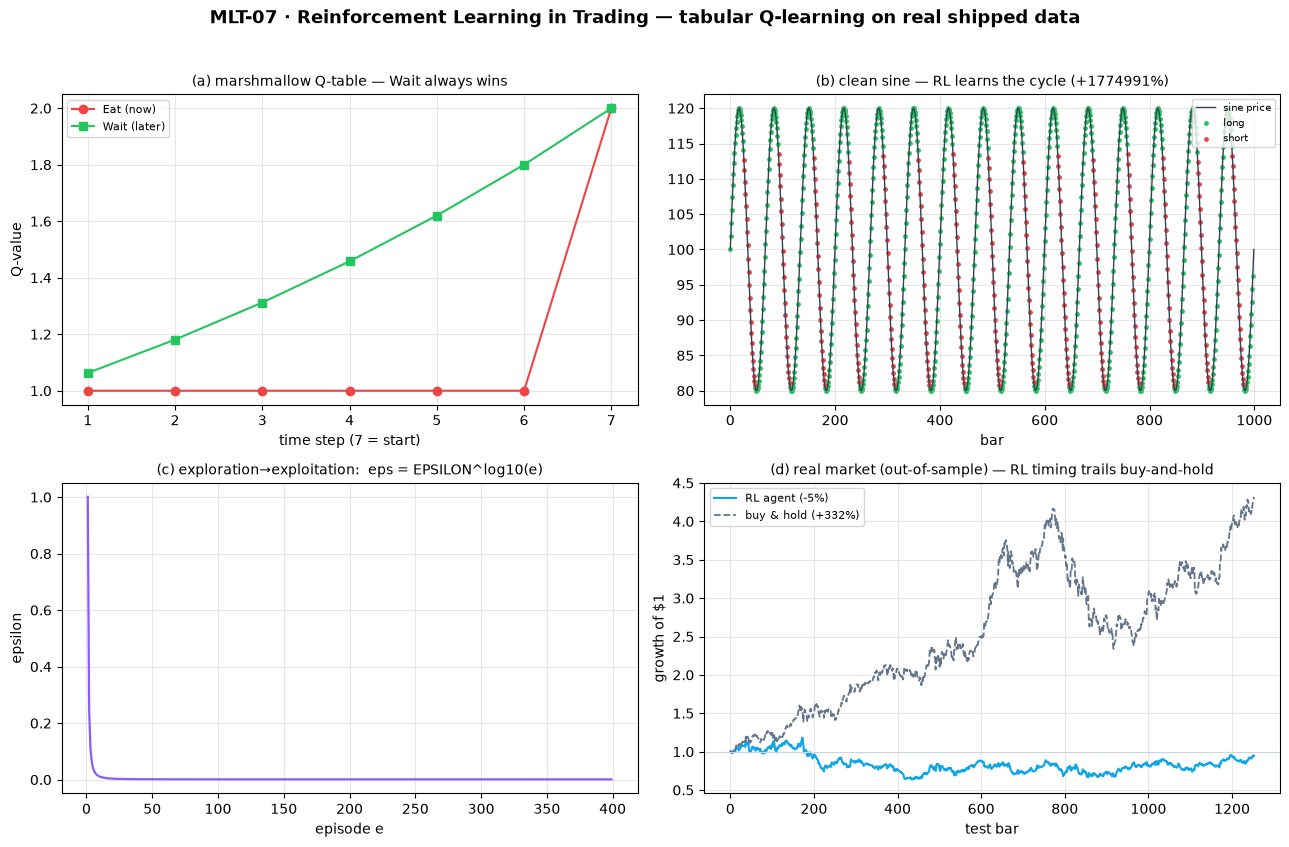

saved chart_1_rl.png


In [15]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8.6))
fig.suptitle("MLT-07 · Reinforcement Learning in Trading — tabular Q-learning on real shipped data",
             fontweight="bold", fontsize=13)

# (a) marshmallow Q-values
a = ax[0, 0]
tt = list(range(1, 8))
a.plot(tt, [Q_eat[t] for t in tt], "o-", color="#ef4444", label="Eat (now)")
a.plot(tt, [Q_wait[t] for t in tt], "s-", color="#22c55e", label="Wait (later)")
a.set_title("(a) marshmallow Q-table — Wait always wins", fontsize=10)
a.set_xlabel("time step (7 = start)"); a.set_ylabel("Q-value"); a.legend(fontsize=8); a.grid(alpha=.3)

# (b) clean sine wave with agent positions
b = ax[0, 1]
b.plot(sine, color="#334155", lw=1, label="sine price")
longs = np.where(pos_s > 0)[0]; shorts = np.where(pos_s < 0)[0]
b.scatter(longs, sine[longs], s=6, color="#22c55e", label="long")
b.scatter(shorts, sine[shorts], s=6, color="#ef4444", label="short")
b.set_title(f"(b) clean sine — RL learns the cycle ({res_s['strat_tot']:+.0%})", fontsize=10)
b.set_xlabel("bar"); b.legend(fontsize=7, loc="upper right"); b.grid(alpha=.3)

# (c) epsilon decay schedule
c = ax[1, 0]
c.plot(episodes, eps_sched, color="#8b5cf6", lw=1.6)
c.set_title("(c) exploration→exploitation:  eps = EPSILON^log10(e)", fontsize=10)
c.set_xlabel("episode e"); c.set_ylabel("epsilon"); c.grid(alpha=.3)

# (d) real market: RL vs buy-and-hold (test segment)
d = ax[1, 1]
d.plot(res_m["strat_eq"], color="#0ea5e9", lw=1.5, label=f"RL agent ({res_m['strat_tot']:+.0%})")
d.plot(res_m["bh_eq"],   color="#64748b", lw=1.3, ls="--", label=f"buy & hold ({res_m['bh_tot']:+.0%})")
d.axhline(1, color="#cbd5e1", lw=.8)
d.set_title("(d) real market (out-of-sample) — RL timing trails buy-and-hold", fontsize=10)
d.set_xlabel("test bar"); d.set_ylabel("growth of $1"); d.legend(fontsize=8); d.grid(alpha=.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("chart_1_rl.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved chart_1_rl.png")


## Recap — lessons learned (Dr Starke's closing slide)

1. **RL is Bellman all the way down.** `Q(s,a) = r + γ·max Q(s′,a′)` — a Q-table (or a neural net that
   approximates it) scored by immediate reward plus the discounted best future value.
2. **Delayed gratification** is the heart of it: the marshmallow table shows why *Wait* beats *Eat* at every
   step — decisions now have repercussions far in the future.
3. **Gamify trading**: state = market features, actions = hold/long/short, reward = P&L. The agent learns a
   policy, exploring early (high ε) and exploiting later (low ε).
4. **A working RL trader nails a clean sine wave**, degrades on a noisy one, and on a real trending market
   **converges to buy-and-hold** — it rediscovers the obvious optimum rather than a magic edge.
5. **Reward-function design is the hard part** — sign-of-P&L, pure P&L, Sharpe, punish-drawdowns and the rest
   each steer the agent to a different policy.
6. **RL overfits very easily**, mostly learns basic patterns, carries a "zoo" of hyper-parameters, and is
   **not a silver bullet** — market experience is highly advisable. *But* it can occasionally find strategies
   we would never have conceived, which may be optimal in the long run.
